# Explore different api providers
## Most of the financial data providers have paywalls, but there are some free ones you can test out. Here are a few examples:
- [CoinGecko API](https://www.coingecko.com/en/api) - Provides cryptocurrency price data.
- [Alpha Vantage API](https://www.alphavantage.co/) - Offers stock and forex data.
- [NewsAPI](https://newsapi.org/) - Provides news articles from various sources.
- [OpenWeatherMap API](https://openweathermap.org/api) - Offers weather data.
- [COVID-19 API](https://covid19api.com/) - Provides COVID-19 statistics.
- [ExchangeRate-API](https://www.exchangerate-api.com/) - Offers currency exchange rates.
- [Financial Modeling Prep API](https://financialmodelingprep.com/developer/docs/) - Provides financial statements and stock data.
- [Quandl API](https://www.quandl.com/tools/api) - Offers various financial and economic data.
- [IEX Cloud API](https://iexcloud.io/docs/api/) - Provides stock market data.
- [FRED API](https://fred.stlouisfed.org/docs/api/fred/) - Offers economic data from the Federal Reserve.
- [Yahoo Finance API](https://finance.yahoo.com/) - Provides stock market data (unofficial API).
- [World Bank API](https://datahelpdesk.worldbank.org/knowledgebase/articles/889386-developer-information-overview) - Offers global economic data.
- [OpenCorporates API](https://api.opencorporates.com/documentation/API-Reference) - Provides company data.
- [EIA API](https://www.eia.gov/opendata/) - Offers energy data.
- [Quandl API](https://www.quandl.com/tools/api) - Provides various financial and economic data.
- [IEX Cloud API](https://iexcloud.io/docs/api/) - Offers stock market data.
- [FRED API](https://fred.stlouisfed.org/docs/api/fred/)
- [Yahoo Finance API](https://finance.yahoo.com/) - Provides stock market data (unofficial API).
- [World Bank API](https://datahelpdesk.worldbank.org/knowledgebase/articles/889386-developer-information-overview) - Offers global economic data. 
- [OpenCorporates API](https://api.opencorporates.com/documentation/API-Reference) - Provides company data.
- [EIA API](https://www.eia.gov/opendata/) - Offers energy


In [ ]:
import requests
import csv
from datetime import datetime
import re # Added for splitting text into words

url = "https://api.coingecko.com/api/v3/simple/price?ids=bitcoin&vs_currencies=usd"

response = requests.get(url)
data = response.json()

price_usd = data["bitcoin"]["usd"]
time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

with open("../data/prices.csv", "a", newline="") as file:
    writer = csv.writer(file)
    writer.writerow([time, price_usd])

print(f"Saved: {time} - {price_usd}")

Saved: 2026-03-27 13:20:41 - 66621


In [17]:
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_INTRADAY&symbol=IBM&interval=5min&apikey=6PWSQFKABIQN68M8'
r = requests.get(url)
data = r.json()

print(data)

url = 'https://www.alphavantage.co/query?function=TIME_SERIES_INTRADAY&symbol=IBM&interval=5min&apikey=6PWSQFKABIQN68M8'
r = requests.get(url)
data = r.json()

print(data)

{'Information': 'Thank you for using Alpha Vantage! This is a premium endpoint. You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly unlock all premium endpoints'}
{'Information': 'Thank you for using Alpha Vantage! Please consider spreading out your free API requests more sparingly (1 request per second). You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to lift the free key rate limit (25 requests per day), raise the per-second burst limit, and instantly unlock all premium endpoints'}


In [18]:
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_INTRADAY&symbol=IBM&interval=5min&apikey=6PWSQFKABIQN68M8'
r = requests.get(url)
data = r.json()

print(data)

{'Information': 'Thank you for using Alpha Vantage! Please consider spreading out your free API requests more sparingly (1 request per second). You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to lift the free key rate limit (25 requests per day), raise the per-second burst limit, and instantly unlock all premium endpoints'}


In [19]:
import requests
import json

url = 'https://api.mboum.com/v1/markets/search'
params = {
  'search': 'AA',
}
headers = {
  'Authorization': 'Bearer {YOUR_AUTH_KEY}'
}

response = requests.request('GET', url, headers=headers, params=params)
response.json()

{'success': False,
 'message': 'You do not have an active subscription. Please subscribe here: https://mboum.com/user/subscriptions/pricing'}

# The following is API for newsapi.org, which provides news articles. You can sign up for a free API key to test it out.

In [ ]:
import os

import requests
import csv
from datetime import datetime
import matplotlib.pyplot as plt

# Obtain an API key from https://newsapi.org/ and save data about news articles mentioning the European Union to a CSV file.

def get_news_newsapi(key_word, language, from_date="2026-03-25", to_date="2026-03-27", 
                     sort_by="publishedAt", page=1, API_KEY="474e30d0bfb94296885ab33fb3e3d27d"):
    """Return a list of dictionaries containing information about news articles mentioning the key word in the specified language.
    Each dictionary contains the title, source, and publication date of an article.
    Also return the publication date of the first and last articles in the list.
    Articles are saved to a CSV file named news.csv in the data directory.
    """
    
    # Loop through pages of results until there are no more articles to retrieve
    articles = []
    while True:
        url = f"https://newsapi.org/v2/everything?q={key_word}&from={from_date}&to={to_date}&page={page}&sortBy={sort_by}&language={language}&apiKey={API_KEY}"
        
        response = requests.get(url)
        data = response.json()

        # Error handling for API requests
        if response.status_code != 200: # Check if the request was successful
            print(f"\nError: {response.status_code} {response.reason}") 
            if response.status_code == 426: # Check if the error is due to too many requests
                print(f"For the free plan we have a speed limit about 5 requests per minute. ")
            else:
                print("Only allow date upto one month ago.")
                print("Only allow 50 request per 12 hours.")
            
            return articles, len(articles), sort_by
            
        else:
            articles_page = data["articles"]    
            articles.extend(articles_page)
            page += 1
            print(f"Total {len(articles_page)} articles saved from page {page-1}...")

            if len(articles_page) == 0  or page > 100: # Check if there are less than 30 articles in the current page or if we have retrieved more than 100 pages (to avoid infinite loop)
                print(f"\n{data['totalResults']} articles found.") 
                print(f"The most {len(articles)} {sort_by} articles are downloaded.")
                return articles, len(articles), sort_by

def save_news_articles_to_csv(articles, file_name):
    """Save a list of article dictionaries to a CSV file."""
    # Save the information about each article to a CSV file
    # Create a CSV file and write the header row
    try:
        BASE_DIR = os.path.dirname(os.path.abspath(__file__))  # script
    except NameError:
        BASE_DIR = os.getcwd()  # notebook

    DATA_DIR = os.path.join(BASE_DIR, "..", "data")
    os.makedirs(DATA_DIR, exist_ok=True)
    file_path = os.path.join(DATA_DIR, f"news_{file_name}.csv")

    with open(f"{file_path}", "w", newline="", encoding="utf-8") as file: # use "w" to overwrite the file each time, instead of "a" to append to the file
        writer = csv.writer(file)
        
        for article in articles:
            title = article["title"]
            source = article["source"]["name"]
            date = datetime.strptime(article["publishedAt"] , "%Y-%m-%dT%H:%M:%SZ")
            url = article["url"]
            writer.writerow([date, source, title, url])
    print(f"\nSaved {len(articles)} articles to ../data/news_{file_name}.csv")

def get_dates(articles):
    """Return the publication date of the first and last articles in the list."""
    try:
        dates = [datetime.strptime(article["publishedAt"], "%Y-%m-%dT%H:%M:%SZ") for article in articles]
    except ValueError as e:
        print(f"Error parsing dates: {e}")
        return None, None

    first_date = min(dates) if dates else None
    last_date = max(dates) if dates else None
    print(f"First article published at: {first_date}")
    print(f"Last article published at: {last_date}")
    return first_date.strftime("%Y-%m-%dT%H:%M:%SZ"), last_date.strftime("%Y-%m-%dT%H:%M:%SZ"),


# Some data cleaning and visualization functions
def remove_grammatical_words(article):
    """Return a list of words with common grammatical words removed from article."""
    words_to_remove = ["the", "is", "and", "of", "to", "in", "a", "that", "it","its",
                       "your","his","her","their","our","my","you","he","she","they",
                       "with","says","for","on","as","was","by","at","from","be",
                       "are","this","which","an","has","have","but","not","or",
                       "s","a","w","i","n","t","l","m","d","u","r","c","e","f","g",
                       "h","j","k","q","v","x","y","z",
                       "how", "what", "who", "when", "where", "why", "all", "any", "some", "no",
                       "can", "could", "should", "would", "may", "might", "must", "will", "shall",
                       "do", "does", "did", "have", "has", "had", "be", "am", "is", "are", "was", 
                       "were", "been", "being", "i", "you", "he", "she", "it", "we", "they", "me", "him", "her",
                       "just","one","into","up","out","about","over","after","before","between","under","then","once","here","there","when","where","why","how","all","any"]

    return [word for word in article if word not in words_to_remove]

def dict_counting(article, dict=None):
    """Return a dictionary that adds new keys to be words in article and values to be counts of those words."""
    if dict is None:
        dict = {}
    for word in article[:]:
        if word in dict.keys():
            dict[word] += 1
        else:
            dict[word] = 1

    return dict

def sort_truncate_dict(count_dict, threshold=3):
    """Return a sorted dictionary with keys as words and values as counts, truncated to only include words with counts above the threshold."""
    sorted_counts = dict(
        sorted(count_dict.items(), key=lambda item: item[1], reverse=True)
    )
    sorted_counts_truncated = {}
    for word, count in sorted_counts.items():
        if count >= threshold:
            sorted_counts_truncated[word] = count

    return sorted_counts_truncated

def bar_chart(count_dict, key_word="key word", first_date="first date", last_date="last date",total_articles=None,sort_by=None,figure_size=(12,12), dpi_number=120,x_int_step=1):
    """Return a bar chart of a given dictionary with keys as words and values as counts."""

    words = list(count_dict.keys())
    counts = list(count_dict.values())

    figure = plt.figure(figsize=figure_size,dpi=dpi_number)
    plt.barh(words,counts, 
            color='skyblue',
            edgecolor='black')
    if total_articles and sort_by:
        plt.title(f"Counts of Words in the Most {total_articles} {sort_by} News Articles Mentioning the {key_word} "
                f"\nfrom {first_date} to {last_date}")
    else:
        plt.title(f"Counts of Words in News Articles Mentioning {key_word} "
                  f"\nfrom {first_date} to {last_date}")
    plt.xlabel("Counts")
    plt.ylabel("Words")

    # Invert y-axis to have the highest counts at the top
    plt.gca().invert_yaxis()
    # set x-axis short ticks to be integers
    plt.xticks(range(0, max(counts)+1, x_int_step))
    
    # plt.xticks(rotation=-90, ha='left') # Rotate x-axis labels by -45 degrees and align them to the left
    plt.grid(axis='x', linestyle='--', alpha=0.3)

    plt.tight_layout()

    return figure


In [5]:

import re
import os 
key_word='euro* OR eu' # You can change the key word to search for different topics. The * is a wildcard that allows for variations of the word (e.g. netherla* will match netherlands, netherland, etc.)
#api_key = "523e9f2aec9748ed945635ddca3c872b"

articles, total_articles, sort_by = get_news_newsapi(key_word=key_word, from_date="2026-03-01", to_date="2026-03-29", language='en',sort_by='relevancy')
first_date, last_date  = get_dates(articles)
save_news_articles_to_csv(articles, file_name=f"{first_date[:10]}_{last_date[:10]}")

if not articles:
    print("No articles found. Exiting.")
else:
    count_dict= {}
    for article in articles:
        source =  [
        w for w in re.split(r"[^a-z]+", article["title"].lower())
        if w
        ] #split by anything that is not a letter and remove empty strings
        article = remove_grammatical_words(source)
        count_dict = dict_counting(article, count_dict)
    print(f"\nTotal {len(count_dict)} unique words found in the articles. Now we can continue to the nexxt step of visualizing ...")

Total 77 articles saved from page 1...
Total 96 articles saved from page 2...
Total 88 articles saved from page 3...
Total 99 articles saved from page 4...
Total 97 articles saved from page 5...

Error: 426 Upgrade Required
For the free plan we have a speed limit about 5 requests per minute. 
First article published at: 2026-03-01 13:38:02
Last article published at: 2026-03-28 13:40:33

Saved 457 articles to ../data/news_2026-03-01_2026-03-28.csv

Total 2139 unique words found in the articles. Now we can continue to the nexxt step of visualizing ...


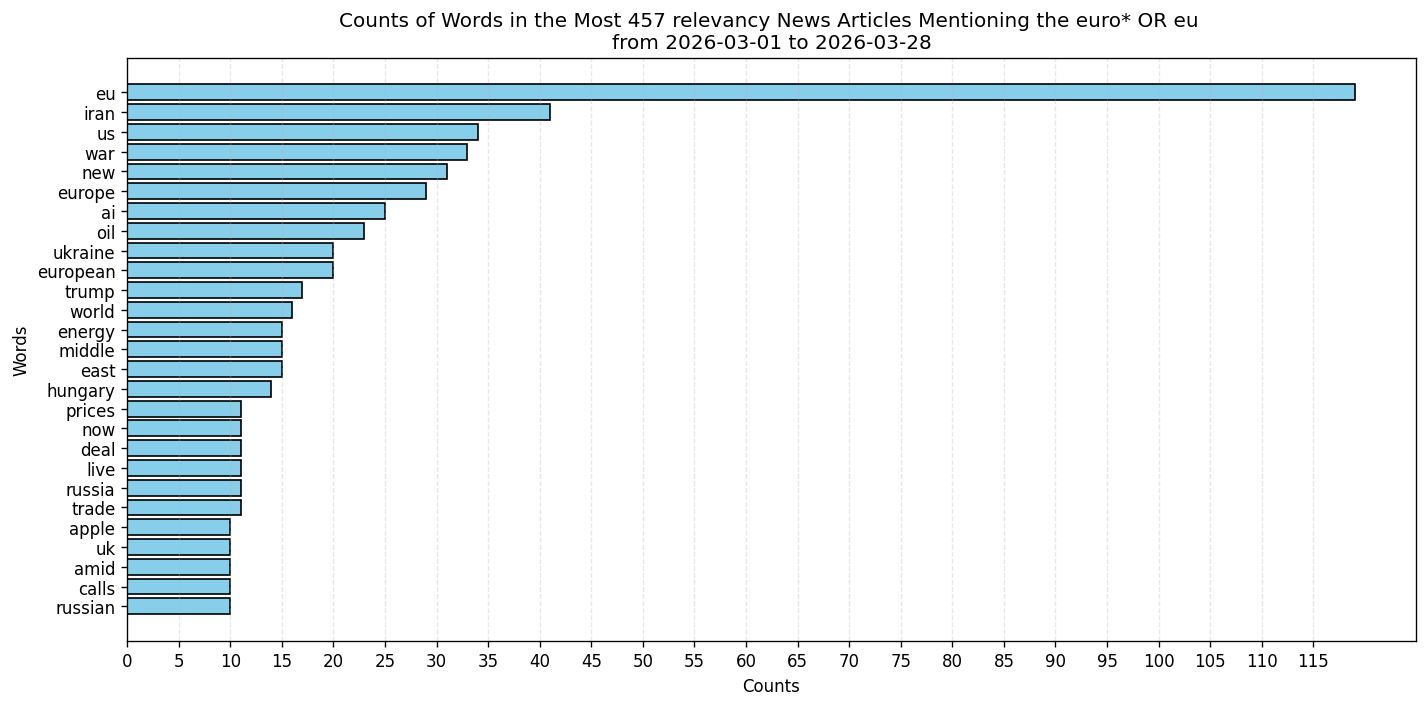

In [7]:
# If the above is successul we can visualize the counts of words in the articles using a bar chart. 
sorted_counts_limited = sort_truncate_dict(count_dict, threshold=10)
figure = bar_chart(sorted_counts_limited, key_word=key_word, first_date=first_date[:10], total_articles=total_articles, sort_by=sort_by, last_date=last_date[:10], figure_size=(12,6),x_int_step=5)

plt.show()

# explore the api
- I need to loop through pages of results. Each page only contains 100 results. 

In [139]:
key_word = 'Europ* eu'
language = 'en'
from_date = "2026-03-20"
to_date = "2026-03-22"

API_KEY = "2645b805eac24bb3a1d045de0cd7f7d4"

page = 1
with open(f"../data/news_{from_date}_{to_date}.csv", "w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["date", "source", "title", "url"]) # write header row
while True:
    url = f"https://newsapi.org/v2/everything?q={key_word}&from={from_date}&to={to_date}&page={page}&sortBy=publishedAt&language={language}&apiKey={API_KEY}"
    response = requests.get(url)
    data = response.json()

    try:
        articles = data["articles"]
        print(f"{data['totalResults']} articles found.") 
        print(f"First article published at: {first_date}")
        print(f"Last article published at: {last_date}")

        # Save the information about each article to a CSV file
        with open(f"../data/news_{from_date}_{to_date}.csv", "a", newline="", encoding="utf-8") as file: # use "w" to overwrite the file each time, instead of "a" to append to the file
            writer = csv.writer(file)
            
            for article in articles:
                title = article["title"]
                source = article["source"]["name"]
                date = datetime.strptime(article["publishedAt"] , "%Y-%m-%dT%H:%M:%SZ")
                url = article["url"]

        print(len(articles), "articles saved to CSV file.")
        print(f"Page {page} completed. Moving to the next page...")
        page += 1
        if len(articles) == 0 or len(articles) < 10:
            break
    except KeyError:
        try:
            print(f"Error: {data['code']}")
            print(f"Message: {data['message']}")
            articles = []
            break
        except Exception as e:
            print(f"An unexpected error occurred: {e}")
            articles = []
            break 








274 articles found.
First article published at: 2026-03-17
Last article published at: 2026-03-27
97 articles saved to CSV file.
Page 1 completed. Moving to the next page...
274 articles found.
First article published at: 2026-03-17
Last article published at: 2026-03-27
97 articles saved to CSV file.
Page 2 completed. Moving to the next page...
274 articles found.
First article published at: 2026-03-17
Last article published at: 2026-03-27
73 articles saved to CSV file.
Page 3 completed. Moving to the next page...
274 articles found.
First article published at: 2026-03-17
Last article published at: 2026-03-27
0 articles saved to CSV file.
Page 4 completed. Moving to the next page...


In [ ]:
def get_news_newsapi(key_word, language, from_date="2026-03-20", to_date="2026-03-27", page =1, API_KEY="2645b805eac24bb3a1d045de0cd7f7d4"):
    """Return a list of dictionaries containing information about news articles mentioning the key word in the specified language.
    Each dictionary contains the title, source, and publication date of an article.
    Also return the publication date of the first and last articles in the list.
    Articles are saved to a CSV file named news.csv in the data directory.
    """
    # Create a CSV file and write the header row
    file_path = f"../data/news_{from_date}_{to_date}.csv"
    with open(f"{file_path}", "w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow(["date", "source", "title", "url"])
    
    # Loop through pages of results until there are no more articles to retrieve
    dates = []
    article_list = []
    with open(f"{file_path}", "w", newline="", encoding="utf-8") as file:
        writer = csv.writer(file)
        writer.writerow(["date", "source", "title", "url"])
    while True:
        print(f"Page {page}...")
        url = f"https://newsapi.org/v2/everything?q={key_word}&from={from_date}&to={to_date}&page={page}&sortBy=publishedAt&language={language}&apiKey={API_KEY}"
        
        response = requests.get(url)
        data = response.json()
        if response.status_code != 200: # Check if the request was successful
            print(f"Error: {response.status_code} {response.reason}")
            print("Only allow date upto one month ago.")
            print("Only allow 50 request per 12 hours.")
            return [], None, None
            
        else:
            articles=data["articles"]
            dates.extend([datetime.strptime(article["publishedAt"], "%Y-%m-%dT%H:%M:%SZ") for article in articles])
            # Save the information about each article to a CSV file
            with open(f"{file_path}", "a", newline="", encoding="utf-8") as file: # use "w" to overwrite the file each time, instead of "a" to append to the file
                writer = csv.writer(file)
                
                for article in articles:
                    title = article["title"]
                    source = article["source"]["name"]
                    date = datetime.strptime(article["publishedAt"] , "%Y-%m-%dT%H:%M:%SZ")
                    url = article["url"]
                writer.writerow([date, source, title, url])

            
            article_list.extend(articles)
            page += 1

            if len(articles) < 30:
                first_date = min(dates) if dates else None
                last_date = max(dates) if dates else None
                print(f"{data['totalResults']} articles found.") 
                print(f"First article published at: {first_date}")
                print(f"Last article published at: {last_date}")
                return articles, first_date.strftime("%Y-%m-%dT%H:%M:%SZ"), last_date.strftime("%Y-%m-%dT%H:%M:%SZ")
                break

get_news_newsapi(key_word="euro* eu", from_date="2026-03-20", to_date="2026-03-27", page =10, language='en')

Page 10...
Error: 426 Upgrade Required
Only allow date upto one month ago.
Only allow 50 request per 12 hours.


([], None, None)

In [16]:
import os

try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))  # script
    print(f"BASE_DIR: {BASE_DIR}")
except NameError:
    BASE_DIR = os.getcwd()  # notebook
    print(f"BASE_DIR: {BASE_DIR}")

DATA_DIR = os.path.join(BASE_DIR, "data")
os.makedirs(DATA_DIR, exist_ok=True)

BASE_DIR: /Users/edward/python_workspace/python-data-analysis/news_api_counting_statistics/notebooks
